In [1]:
# データ加工・処理・分析ライブラリ
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd
# 可視化ライブラリ
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline
# 機械学習ライブラリ
import sklearn
# 小数第 3 位まで表示
%precision 3

'%.3f'

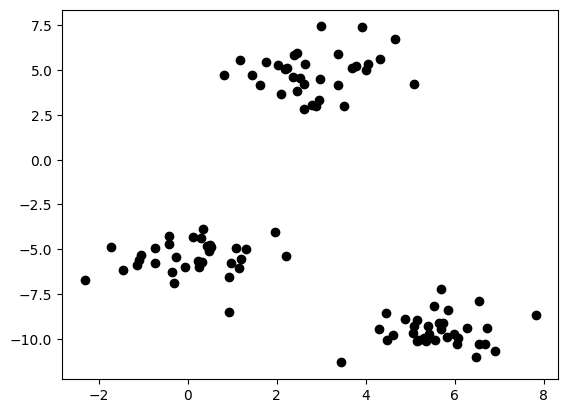

In [2]:
# k-means 法を使うためのインポート
from sklearn.cluster import KMeans
# データ取得のためのインポート
from sklearn.datasets import make_blobs
# サンプルデータ生成
# 注意：make_blobs は 2 つの値を返すため、一方は使用しない「 _ 」で受け取る
X, _ = make_blobs(random_state=10)
# グラフを描画
# color のオプションで色付けができる
plt.scatter(X[:,0],X[:,1],color='black')

In [3]:
# KMeans クラスの初期化
kmeans = KMeans(init='random',n_clusters=3)
# クラスターの重心を計算
kmeans.fit(X)
# クラスター番号を予測
y_pred = kmeans.predict(X)

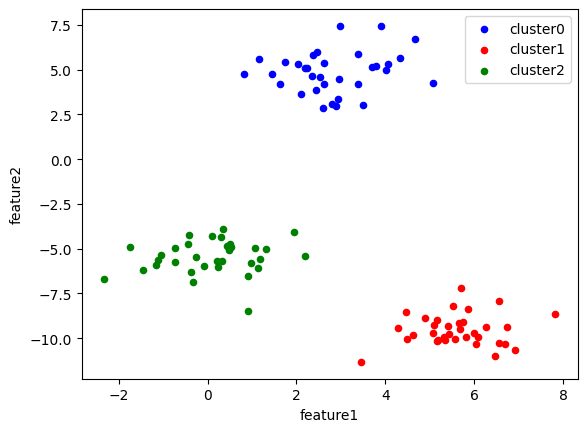

In [4]:
# concat でデータを横に結合 (axis=1 を指定 )
merge_data = pd.concat([pd.DataFrame(X[:,0]), pd.DataFrame(X[:,1]), pd.DataFrame(y_pred)], axis=1)
# 上記のデータにて、X 軸を feature1、Y 軸を feature2、クラスター番号を cluster と列名指定
merge_data.columns = ['feature1','feature2','cluster']
# クラスタリング結果のグラフ化
ax = None
colors = ['blue', 'red', 'green']
for i, data in merge_data.groupby('cluster'):
    ax = data.plot.scatter(x='feature1', y='feature2', color=colors[i], label=f'cluster{i}', ax=ax)

In [5]:
# web からデータを取得したり、zip ファイルを扱うためのライブラリをインポート
import requests, zipfile
import io
# データがある url の指定
zip_file_url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'
# データを取得して展開する
r = requests.get(zip_file_url, stream=True)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

In [6]:
# 対象データを読み込み
bank= pd.read_csv('bank-full.csv', sep=';')
# 先頭の 5 行を表示
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
print(' データ形式 (X,y):{}'.format(bank.shape))
print(' 欠損データの数 :{}'.format(bank.isnull().sum().sum()))

 データ形式 (X,y):(45211, 17)
 欠損データの数 :0


In [8]:
from sklearn.preprocessing import StandardScaler
# データの列の絞り込み
bank_sub = bank[['age','balance','campaign','previous']]
# 標準化
sc = StandardScaler()
sc.fit(bank_sub)
bank_sub_std = sc.transform(bank_sub)
bank_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       45211 non-null  int64
 1   balance   45211 non-null  int64
 2   campaign  45211 non-null  int64
 3   previous  45211 non-null  int64
dtypes: int64(4)
memory usage: 1.4 MB


cluster_number
4    14454
0    23791
3     1286
2     3781
5      525
1     1374
Name: count, dtype: int64


Text(0, 0.5, 'count')

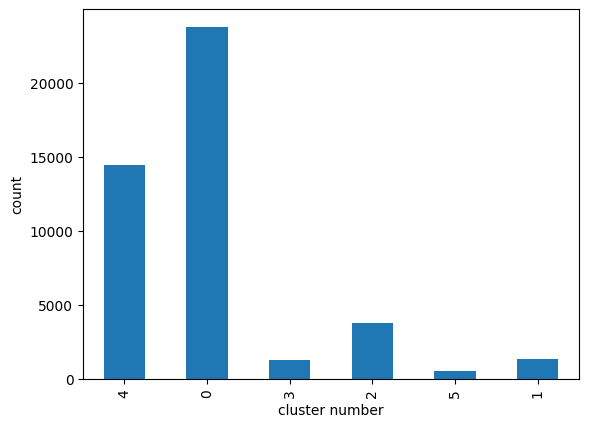

In [9]:
# KMeans クラスの初期化
kmeans = KMeans(init='random', n_clusters=6, random_state=0)
# クラスターの重心を計算
kmeans.fit(bank_sub_std)
# クラスター番号を pandas の Series オブジェクトに変換
labels = pd.Series(kmeans.labels_, name='cluster_number')
# クラスター番号と件数を表示
print(labels.value_counts(sort=False))
# グラフを描画
ax = labels.value_counts(sort=False).plot(kind='bar')
ax.set_xlabel('cluster number')
ax.set_ylabel('count')

Text(0, 0.5, 'Distortion')

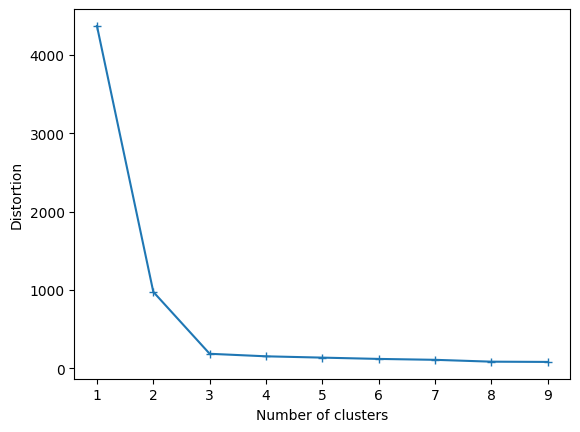

In [10]:
# エルボー方による推定。クラスター数を 1 から 10 に増やして、それぞれの距離の総和を求める
dist_list =[]
for i in range(1,10):
    kmeans= KMeans(n_clusters=i, init='random', random_state=0)
    kmeans.fit(X)
    dist_list.append(kmeans.inertia_)
# グラフを表示
plt.plot(range(1,10), dist_list,marker='+')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')

Text(0, 0.5, 'Distortion')

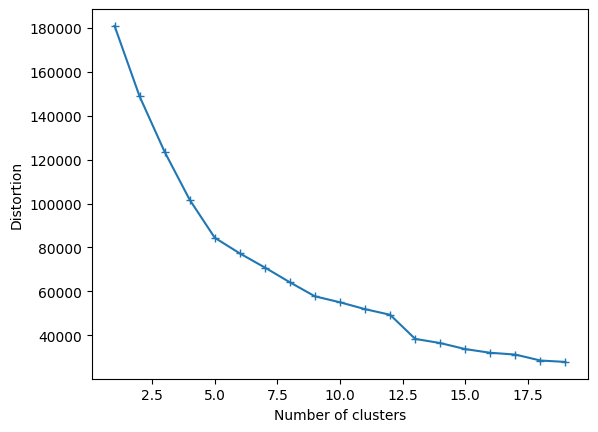

In [11]:
# エルボー方による推定。クラスター数を 1 から 20 に増やして、それぞれの距離の総和を求める
dist_list =[]
for i in range(1,20):
    kmeans= KMeans(n_clusters=i, init='random', random_state=0)
    kmeans.fit(bank_sub_std)
    dist_list.append(kmeans.inertia_)
# グラフを表示
plt.plot(range(1,20), dist_list,marker='+')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')

In [12]:
# 金融機関のデータにクラスター番号のデータを結合
bank_with_cluster = pd.concat([bank, labels], axis=1)
# 先頭の 5 行を表示
bank_with_cluster.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,cluster_number
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,4
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,4
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,4
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


In [13]:
# 分割のための区切りを設定
bins = [15,20,25,30,35,40,45,50,55,60,65,100]
# 上の区切りをもとに金融機関のデータを分割し、qcut_age 変数に各データの年齢層を設定
qcut_age = pd.cut(bank_with_cluster.age, bins, right=False)
# クラスタ番号と年齢層を結合
df = pd.concat([bank_with_cluster.cluster_number, qcut_age], axis=1)
# クラスタ番号と年齢層を軸に集計し、年齢層を列に設定
cross_cluster_age = df.groupby(['cluster_number', 'age']).size().unstack().fillna(0)
cross_cluster_age

age,"[15, 20)","[20, 25)","[25, 30)","[30, 35)","[35, 40)","[40, 45)","[45, 50)","[50, 55)","[55, 60)","[60, 65)","[65, 100)"
cluster_number,,,,,,,,,,,
0,45.0,708.0,3972.0,8272.0,6853.0,3941.0,0.0,0.0,0.0,0.0,0.0
1,0.0,20.0,130.0,327.0,306.0,186.0,145.0,117.0,71.0,38.0,34.0
2,1.0,18.0,233.0,782.0,872.0,739.0,587.0,337.0,175.0,32.0,5.0
3,0.0,11.0,74.0,240.0,219.0,205.0,156.0,141.0,156.0,48.0,36.0
4,0.0,0.0,0.0,0.0,0.0,1022.0,4529.0,3840.0,3479.0,850.0,734.0
5,1.0,5.0,55.0,119.0,99.0,92.0,53.0,53.0,41.0,6.0,1.0


In [14]:
# 分割したデータ数をカウント
hist_age = qcut_age.value_counts()
hist_age

age
[30, 35)     9740
[35, 40)     8349
[40, 45)     6185
[45, 50)     5470
[50, 55)     4488
[25, 30)     4464
[55, 60)     3922
[60, 65)      974
[65, 100)     810
[20, 25)      762
[15, 20)       47
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='cluster_number'>

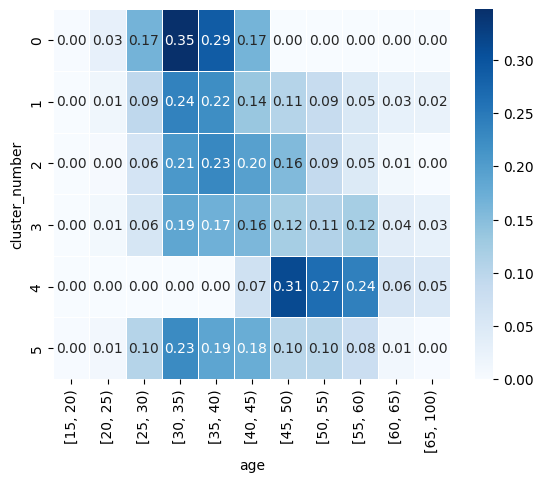

In [15]:
sns.heatmap(cross_cluster_age.apply(lambda x : x/x.sum(), axis=1), cmap='Blues', annot=True, fmt='.2f', linewidths=0.5)

In [16]:
cross_cluster_job = bank_with_cluster.groupby(['cluster_number', 'job']).size().unstack().fillna(0)
cross_cluster_job

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster_number,,,,,,,,,,,,
0,3022,5426,702,413,4980,55,826,2496,814,4290,690,77
1,193,239,42,21,335,53,42,113,53,245,33,5
2,387,845,146,108,863,60,144,358,40,704,90,36
3,109,176,54,36,418,77,71,69,22,194,49,11
4,1414,2915,530,655,2733,2008,477,1077,3,2054,434,154
5,46,131,13,7,129,11,19,41,6,110,7,5


<Axes: xlabel='job', ylabel='cluster_number'>

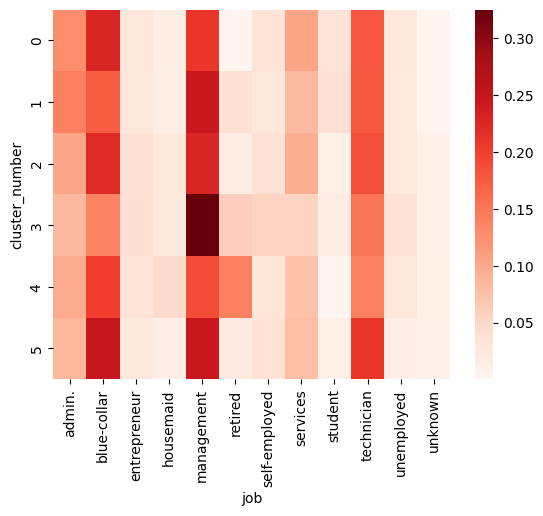

In [17]:
sns.heatmap(cross_cluster_job.apply(lambda x : x/x.sum(), axis=1),cmap='Reds')

In [18]:
#9-3

 相関係数 0.889:


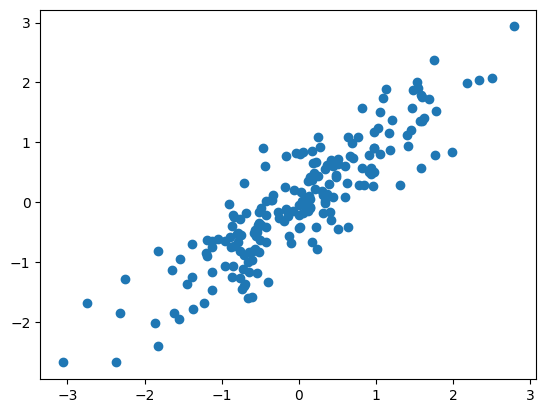

In [19]:
from sklearn.preprocessing import StandardScaler
# RandomState オブジェクトを作成
sample = np.random.RandomState(1)
# ２つの乱数を生成
X = np.dot(sample.rand(2, 2), sample.randn(2, 200)).T
# 標準化
sc = StandardScaler()
X_std = sc.fit_transform(X)
# 相関係数の算出とグラフ化
print(' 相関係数 {:.3f}:'.format(sp.stats.pearsonr(X_std[:, 0], X_std[:, 1])[0]))
plt.scatter(X_std[:, 0], X_std[:, 1])

In [20]:
# インポート
from sklearn.decomposition import PCA
# 主成分分析
pca = PCA(n_components=2)
pca.fit(X_std)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [21]:
print(pca.components_)

[[ 0.707  0.707]
 [ 0.707 -0.707]]


In [25]:
print(' 各主成分の分散 :{}'.format(pca.explained_variance_))

 各主成分の分散 :[1.899 0.111]


In [26]:
print(sum(pca.explained_variance_))

2.010050251256281


In [27]:
print(' 各主成分の分散割合 :{}'.format(pca.explained_variance_ratio_))

 各主成分の分散割合 :[0.945 0.055]


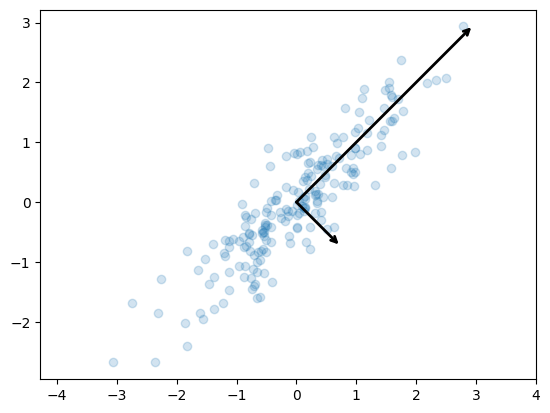

In [28]:
# パラメータ設定
arrowprops=dict(arrowstyle='->',
linewidth=2,
shrinkA=0, shrinkB=0)
# 矢印を描くための関数
def draw_vector(v0, v1):
    plt.gca().annotate('', v1, v0, arrowprops=arrowprops)
# 元のデータをプロット
plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.2)
# 主成分分析の 2 軸を矢印で表示する
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

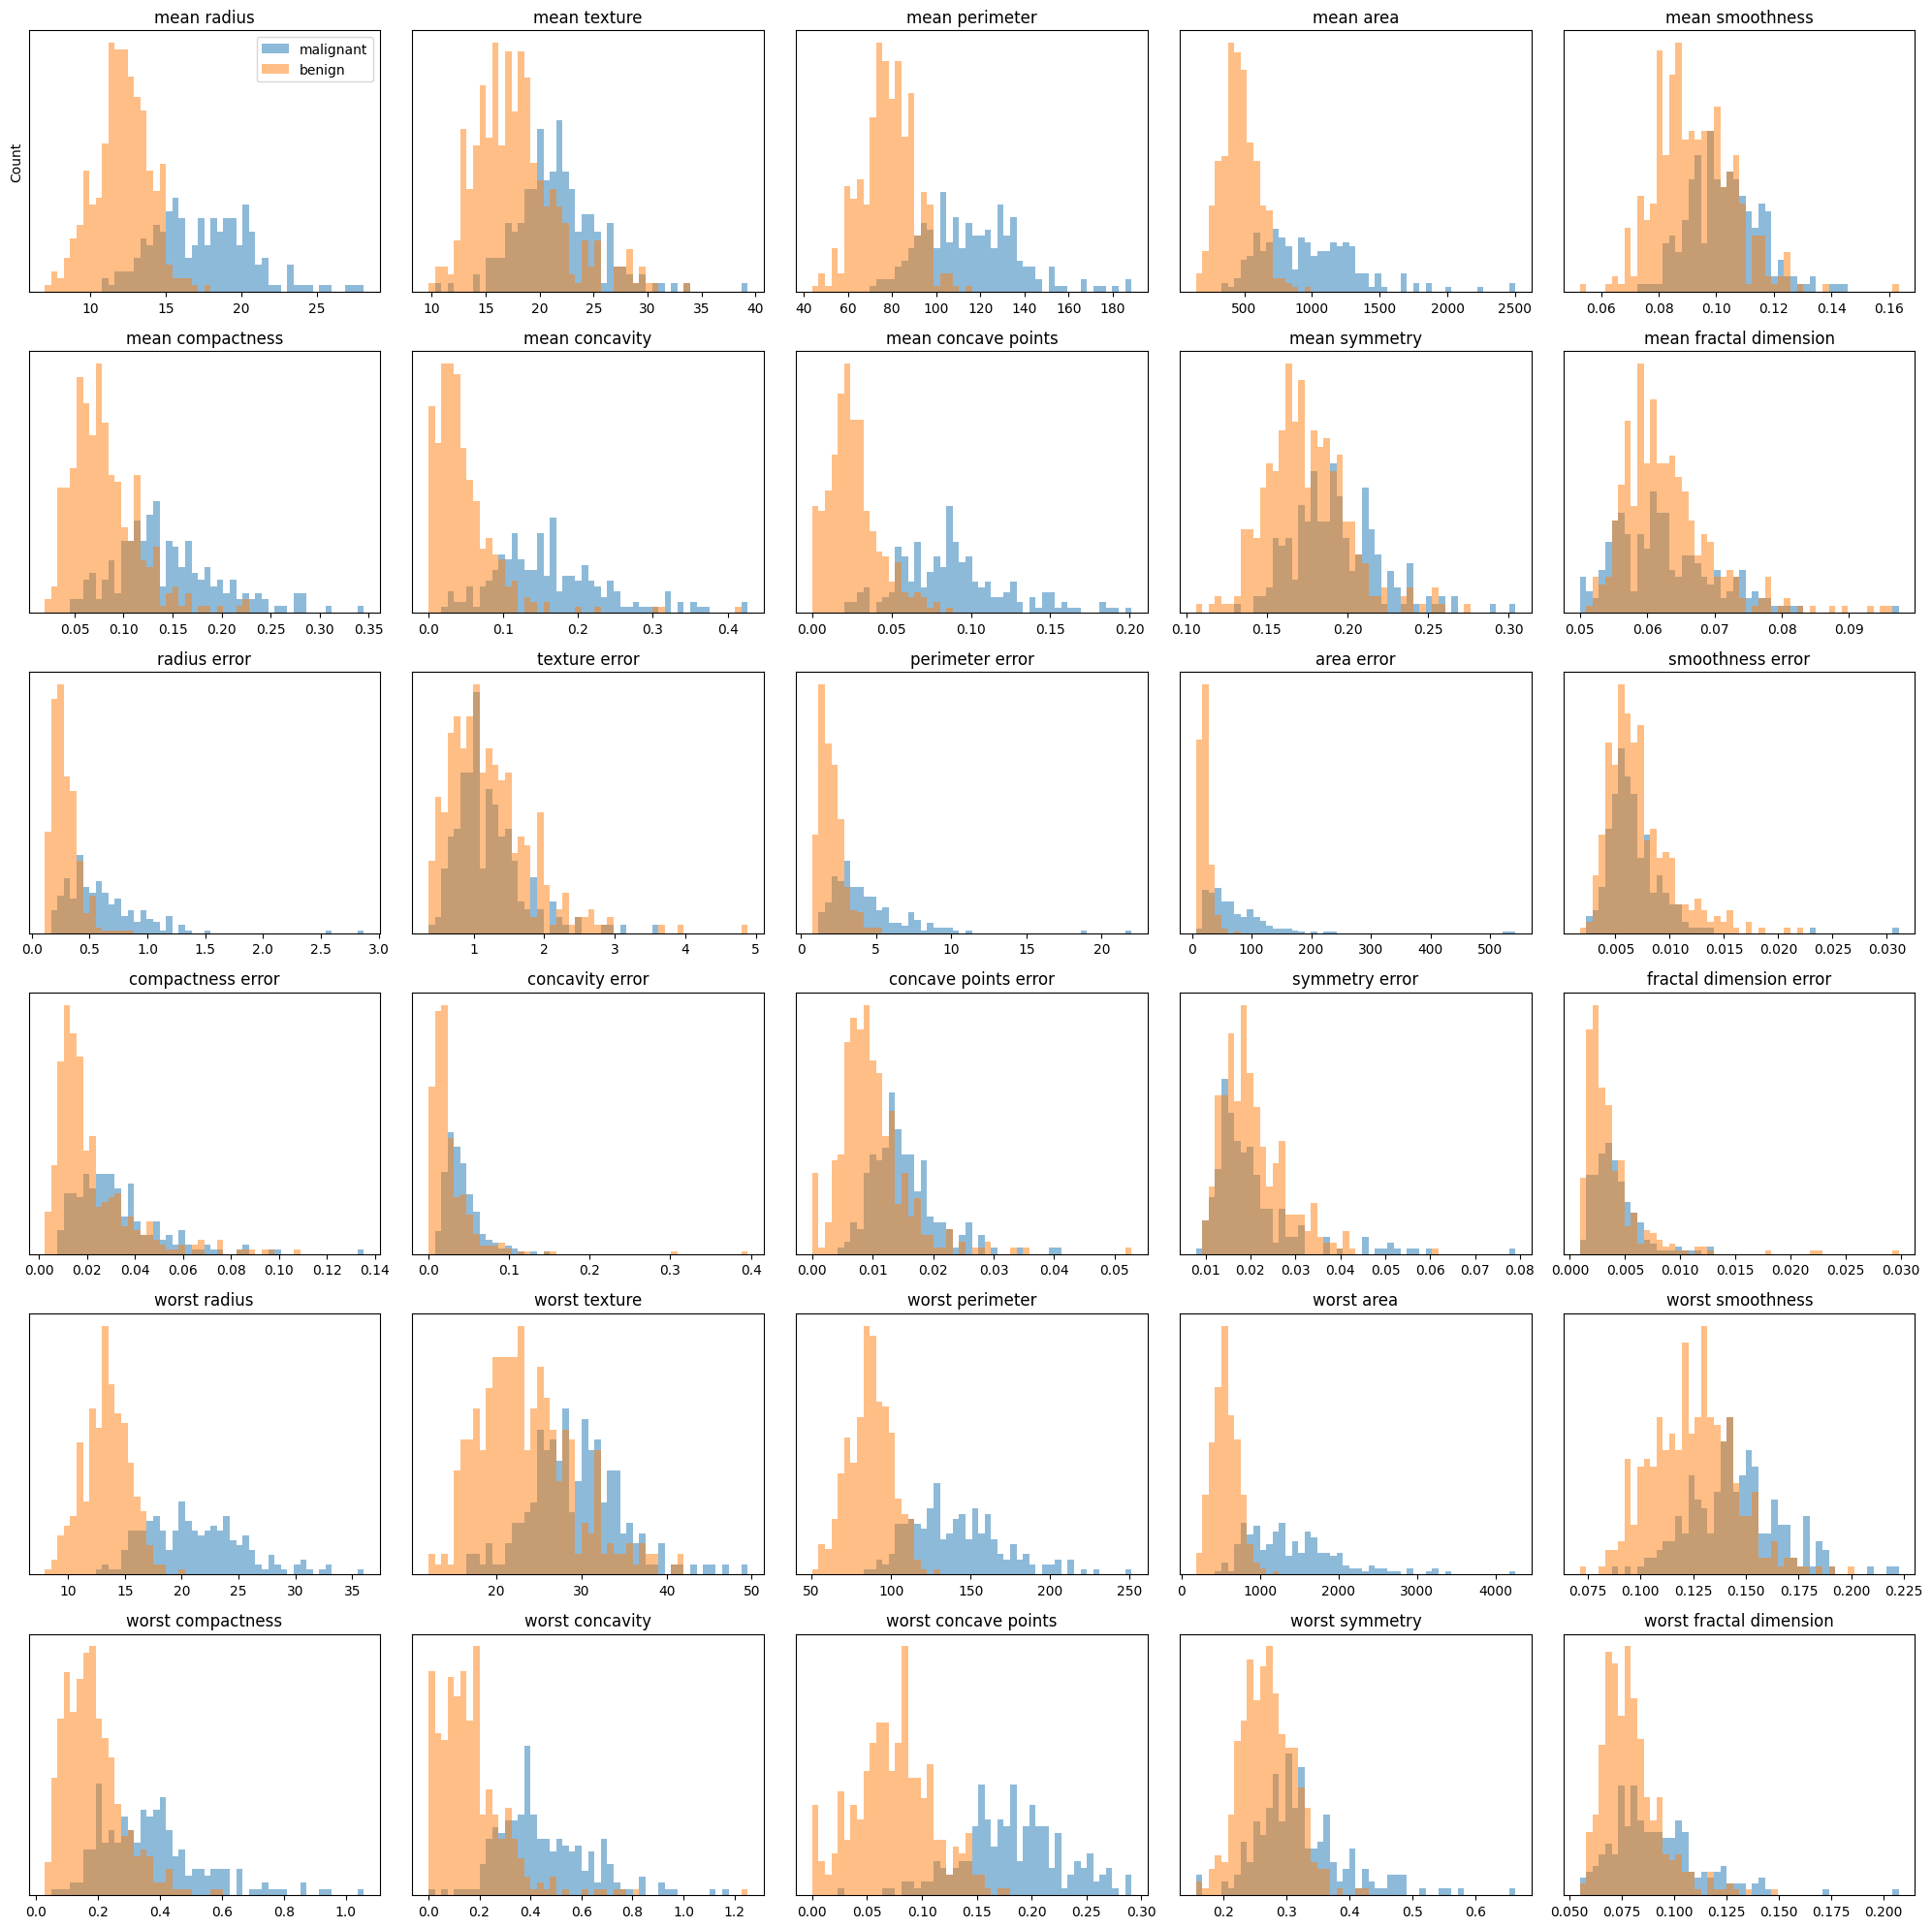

In [29]:
# 乳がんデータを読み込むためのインポート
from sklearn.datasets import load_breast_cancer
# 乳がんデータの取得
cancer = load_breast_cancer()
# データを malignant（悪性）か benign（良性）に分けるためのフィルター処理
# malignant（悪性）は cancer.target が 0
malignant = cancer.data[cancer.target==0]
# benign（良性）は cancer.target が 0
benign = cancer.data[cancer.target==1]
# malignant（悪性）がブルー、benign（良性）がオレンジのヒストグラム
# 各図は、各々の説明変数（mean radius など）と目的変数との関係を示したヒストグラム
fig, axes = plt.subplots(6,5,figsize=(20,20))
ax = axes.ravel()
for i in range(30):
    _,bins = np.histogram(cancer.data[:,i], bins=50)
    ax[i].hist(malignant[:,i], bins, alpha=.5)
    ax[i].hist(benign[:,i], bins, alpha=.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())
# ラベルの設定
ax[0].set_ylabel('Count')
ax[0].legend(['malignant','benign'],loc='best')
fig.tight_layout()

In [30]:
# 標準化
sc = StandardScaler()
X_std = sc.fit_transform(cancer.data)
# 主成分分析
pca = PCA(n_components=2)
pca.fit(X_std)
X_pca = pca.transform(X_std)
# 表示
print('X_pca shape:{}'.format(X_pca.shape))
print('Explained variance ratio:{}'.format(pca.explained_variance_ratio_))

X_pca shape:(569, 2)
Explained variance ratio:[0.443 0.19 ]


In [31]:
# 列にラベルをつける、1 つ目が第 1 主成分、2 つ目が第 2 主成分
X_pca = pd.DataFrame(X_pca, columns=['pc1','pc2'])
# 上のデータに、目的変数（cancer.target）を紐づける、横に結合
X_pca = pd.concat([X_pca, pd.DataFrame(cancer.target, columns=['target'])], axis=1)
# 悪性、良性を分ける
pca_malignant = X_pca[X_pca['target']==0]
pca_benign = X_pca[X_pca['target']==1]

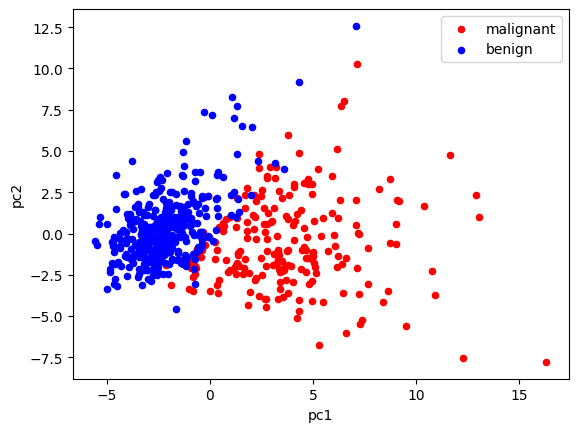

In [32]:
# 悪性をプロット
ax = pca_malignant.plot.scatter(x='pc1', y='pc2', color='red', label='malignant');
# 良性をプロット
pca_benign.plot.scatter(x='pc1', y='pc2', color='blue', label='benign', ax=ax);